In [1]:
%load_ext autoreload
%autoreload 2

import os, glob, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 as cosmo
from astropy import units as u, constants as c

from equipartition import *

from otter import Otter
db = Otter(datadir="private-data")

import syncfit

def get_bounds(chain, ndim=3):
    
    medians, upper, lower = [], [], []
    for i in range(ndim):
        mcmc = np.percentile(chain[:, i], [16, 50, 84])
        q = np.diff(mcmc)
        vals = [mcmc[1],(q[0]+q[1])/2]

        medians.append(mcmc[1])
        upper.append(q[1])
        lower.append(q[0])

    return medians, upper, lower

def get_single_bound(chain1d):
    mcmc = np.percentile(chain1d, [16, 50, 84])
    q = np.diff(mcmc)
    
    return mcmc[1], q[1], q[0]

conf_level = 0.95

Attempting to login to https://otter.idies.jhu.edu/api with the following credentials:
username: user-guest
password: test


In [2]:
param_uplims = dict(
    name = ['SDSSJ1241', 'SDSSJ1241', 'SDSSJ0938', 'SDSSJ0748'],
    mjd = ['60967.0', '57959.0', '57912.0', '57914.0'],
    p_lim = [False, False, False, False], # these would be upperlimits
    p_lim_type = ["upper"]*4,
    log_F_nu_lim = [False, False, True, True], # these are lower limits
    log_F_nu_lim_type = ["lower"]*4,
    log_nu_a_lim = [False, False, True, True], # these are upperlimits on nu_a
    log_nu_a_lim_type = ["upper"]*4
)

In [3]:
labels = ["p", 'log_F_nu', 'log_nu_a']

best_fit_params = dict(
    name = [],
    mjd = [],
    p = [],
    p_up = [],
    p_lo = [],
    p_chain = [],
    log_F_nu = [],
    log_F_nu_up = [],
    log_F_nu_lo = [],
    log_F_nu_chain = [],
    log_nu_a = [],
    log_nu_a_up = [],
    log_nu_a_lo = [],
    log_nu_a_chain = []
)
ii = 0
for jfile in glob.glob(os.path.join(os.getcwd(), "*chains.json")):

    if "SDSSJ0952" in jfile: continue # skip J0952, for now...

    with open(jfile, "r") as j:
        chain_dict = json.load(j)
    
    tname = jfile.split('-')[1].split('/')[1]

    print(tname)

    for k, chain in chain_dict.items():
        medians, uplims, lowlims = get_bounds(np.array(chain))
        print(f"\tMJD = {k}")
        for median, uplim, lowlim, lab, chain_by_key in zip(medians, uplims, lowlims, labels, np.array(chain).T):
            print(f"\t\t${lab} = {median:.2f}^+{uplim:.2f}_-{lowlim:.2f}$")

            print(ii, lab, param_uplims[lab+"_lim"][ii])
            if param_uplims[lab+"_lim"][ii]:
                if param_uplims[lab+"_lim_type"][ii] == "upper":
                    limval = np.quantile(chain_by_key, conf_level)
                else:
                    limval = np.quantile(chain_by_key, 1-conf_level)
                    
                best_fit_params[lab].append(limval)
                best_fit_params[f"{lab}_up"].append(0)
                best_fit_params[f"{lab}_lo"].append(0)
            else:
                best_fit_params[lab].append(median)
                best_fit_params[f"{lab}_up"].append(uplim)
                best_fit_params[f"{lab}_lo"].append(lowlim)
            best_fit_params[f"{lab}_chain"].append(chain_by_key)
        best_fit_params["mjd"].append(k)
        best_fit_params["name"].append(tname)
        ii += 1
    
    print()

res = pd.DataFrame(best_fit_params).merge(pd.DataFrame(param_uplims), on=["name", "mjd"])

res

SDSSJ1241
	MJD = 60967.0
		$p = 3.39^+0.09_-0.09$
0 p False
		$log_F_nu = 0.56^+0.02_-0.02$
0 log_F_nu False
		$log_nu_a = 8.86^+0.02_-0.02$
0 log_nu_a False
	MJD = 57959.0
		$p = 3.72^+0.07_-0.07$
1 p False
		$log_F_nu = 0.93^+0.01_-0.01$
1 log_F_nu False
		$log_nu_a = 9.10^+0.02_-0.02$
1 log_nu_a False

SDSSJ0938
	MJD = 57912.0
		$p = 3.05^+0.08_-0.07$
2 p False
		$log_F_nu = 1.34^+0.45_-0.42$
2 log_F_nu True
		$log_nu_a = 8.31^+0.43_-0.44$
2 log_nu_a True

SDSSJ0748
	MJD = 57914.0
		$p = 2.58^+0.32_-0.30$
3 p False
		$log_F_nu = 0.40^+0.85_-0.76$
3 log_F_nu True
		$log_nu_a = 7.67^+1.03_-1.06$
3 log_nu_a True



,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,log_nu_a,log_nu_a_up,log_nu_a_lo,log_nu_a_chain,p_lim,p_lim_type,log_F_nu_lim,log_F_nu_lim_type,log_nu_a_lim,log_nu_a_lim_type
0,SDSSJ1241,60967.0,3.386910,0.087268,0.089066,"[3.2679121079218025, 3.3539253960752884, 3.392...",0.564602,0.016208,0.016039,"[0.5434131282223658, 0.5730810091666221, 0.579...",8.861037,0.01626,0.018337,"[8.855137401218965, 8.860250434060097, 8.85461...",False,upper,False,lower,False,upper
1,SDSSJ1241,57959.0,3.724464,0.069052,0.068371,"[3.621524851919936, 3.689507618302295, 3.70800...",0.926873,0.011062,0.010923,"[0.9245284412643235, 0.9359265452152056, 0.944...",9.097437,0.01557,0.016762,"[9.079079630331103, 9.080317265896305, 9.08433...",False,upper,False,lower,False,upper
2,SDSSJ0938,57912.0,3.053439,0.076760,0.068440,"[3.011181432239487, 2.9513329994447255, 3.1359...",0.814829,0.000000,0.000000,"[1.3183299648733493, 1.6839582654785334, 0.859...",8.877019,0.00000,0.000000,"[8.322775152638208, 7.902578195888486, 8.81266...",False,upper,True,lower,True,upper
3,SDSSJ0748,57914.0,2.580505,0.322214,0.298702,"[2.9580353051773542, 2.793411381802714, 2.4356...",-0.555978,0.000000,0.000000,"[1.7879441414968558, 1.5935250585102143, 1.390...",9.015436,0.00000,0.000000,"[6.643970691090599, 6.467039710616048, 6.04937...",False,upper,True,lower,True,upper


In [4]:
# add in other information we need about each object

SDSSJ1241_meta = db.get_meta(names="SDSS_J1241", query_private=True)[0]
SDSSJ0938_meta = db.get_meta(names="SDSS_J0938", query_private=True)[0]
SDSSJ0748_meta = db.get_meta(names="SDSS_J0748", query_private=True)[0]

redshift = dict(
    SDSSJ1241 = SDSSJ1241_meta.get_redshift(),
    SDSSJ0938 = SDSSJ0938_meta.get_redshift(),
    SDSSJ0748 = SDSSJ0748_meta.get_redshift()
)

disc_date = dict(
    SDSSJ1241 = SDSSJ1241_meta.get_discovery_date().mjd,
    SDSSJ0938 = SDSSJ0938_meta.get_discovery_date().mjd,
    SDSSJ0748 = SDSSJ0748_meta.get_discovery_date().mjd
)

lum_dist = dict(
    SDSSJ1241 = None,
    SDSSJ0938 = None,
    SDSSJ0748 = None
)

# I get all of these velocity dispersions by querying SDSS for the coordinates from the name
vel_disp = dict(
    SDSSJ0748 = 79.33013,
    SDSSJ0938 = 126.8426,
    SDSSJ1241 = 85.12043
)

vel_disp_err = dict(
    SDSSJ0748 = 8.36008,
    SDSSJ0938 = 9.147189,
    SDSSJ1241 = 11.9128
)

for name, z in redshift.items():
    lum_dist[name] = cosmo.luminosity_distance(z).to("cm").value

res['z'] = res.name.map(redshift).astype(float)
res["lum_dist"] = res.name.map(lum_dist).astype(float)
res["disc_date"] = res.name.map(disc_date).astype(float)

res["vel_disp"] = res.name.map(vel_disp).astype(float)
res["vel_disp_err"] = res.name.map(vel_disp_err).astype(float)

# compute the black hole mass using M-sigma
# Using this relation: https://iopscience.iop.org/article/10.1088/0004-637X/698/1/198
def Msigma(sigma_km_s):
    alpha = 8.12
    beta = 4.24
    return alpha + beta*np.log10(sigma_km_s/200)

def Msigma_err(sigma, sigma_err):
    alpha_err = 0.08
    beta_err = 0.41
    alpha = 8.12
    beta = 4.24
    return np.sqrt(alpha_err**2 + (beta*sigma_err/(sigma*np.log(10)))**2)

res["log_M_bh"] = Msigma(res.vel_disp)
res["log_M_bh_err"] = Msigma_err(res.vel_disp, res.vel_disp_err)
res["M_bh"] = 10**res.log_M_bh
res["M_bh_err"] = res.M_bh * (res.log_M_bh_err * np.log(10))

# then calculate the swarschild radius
def R_s(M_bh):
    r_s = 2*c.G*M_bh/c.c**2
    return r_s.cgs.value

res["R_s"] = R_s(res.M_bh.to_numpy()*c.M_sun)
res["R_s_err"] = R_s(res.M_bh_err.to_numpy()*c.M_sun)

res["dt"] = res.mjd.astype(float) - res.disc_date

# determine if each F_nu, p, and log_nu should be upperlimits
def is_upperlimit(df, key, model=syncfit.models.B5(), uplim_factor=3):
    
    key_prior = model.prior[key]
    
    median = df[key]
    up = df[f"{key}_up"]
    lo = df[f"{key}_lo"]
        
    return median+(up*uplim_factor) > key_prior[1]
    
    
res["log_F_nu_uplim"] = is_upperlimit(res, "log_F_nu")
res["log_nu_a_uplim"] = is_upperlimit(res, "log_nu_a")
res["p_uplim"] = is_upperlimit(res, "p")

res

Names have the same score! Just using the existing default_name


,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,log_M_bh,log_M_bh_err,M_bh,M_bh_err,R_s,R_s_err,dt,log_F_nu_uplim,log_nu_a_uplim,p_uplim
0,SDSSJ1241,60967.0,3.386910,0.087268,0.089066,"[3.2679121079218025, 3.3539253960752884, 3.392...",0.564602,0.016208,0.016039,"[0.5434131282223658, 0.5730810091666221, 0.579...",...,6.546976,0.269841,3.523515e+06,2.189272e+06,1.040582e+12,6.465467e+11,7905.0,False,False,False
1,SDSSJ1241,57959.0,3.724464,0.069052,0.068371,"[3.621524851919936, 3.689507618302295, 3.70800...",0.926873,0.011062,0.010923,"[0.9245284412643235, 0.9359265452152056, 0.944...",...,6.546976,0.269841,3.523515e+06,2.189272e+06,1.040582e+12,6.465467e+11,4897.0,False,False,False
2,SDSSJ0938,57912.0,3.053439,0.076760,0.068440,"[3.011181432239487, 2.9513329994447255, 3.1359...",0.814829,0.000000,0.000000,"[1.3183299648733493, 1.6839582654785334, 0.859...",...,7.281477,0.155028,1.911952e+07,6.825016e+06,5.646472e+12,2.015598e+12,3820.0,False,False,False
3,SDSSJ0748,57914.0,2.580505,0.322214,0.298702,"[2.9580353051773542, 2.793411381802714, 2.4356...",-0.555978,0.000000,0.000000,"[1.7879441414968558, 1.5935250585102143, 1.390...",...,6.417251,0.209897,2.613669e+06,1.263204e+06,7.718819e+11,3.730557e+11,4979.0,False,False,False


In [5]:
equipartition_results = dict( 
    name = [],
    mjd = [],
    
    n_e_chain = [],
    n_e = [],
    n_e_up = [],
    n_e_lo = [],
    n_e_lim = [False, False, True, True],
    n_e_lim_type = 'upper',
    
    Req_chain = [],
    Req = [],
    Req_up = [],
    Req_lo = [],
    Req_lim = [False, False, True, True],
    Req_lim_type = 'lower',
    
    Eeq_chain = [],
    Eeq = [],
    Eeq_up = [],
    Eeq_lo = [],
    Eeq_lim = [False, False, True, True],
    Eeq_lim_type = 'lower',
)

for ii, (_, row) in enumerate(res.iterrows()):
    
    equipartition_results["name"].append(row['name'])
    equipartition_results["mjd"].append(row.mjd)
    
    r_eq_val = Req(
        p = row.p_chain, 
        F_p_mJy = 10**row.log_F_nu_chain, 
        nu_p = 10**row.log_nu_a_chain, 
        z = row.z, 
        d_L = row.lum_dist
    )
        
    equipartition_results["Req_chain"].append(r_eq_val)
    req, req_up, req_lo = get_single_bound(r_eq_val)

    if equipartition_results["Req_lim"][ii]:
        equipartition_results["Req"].append(np.quantile(r_eq_val, 1-conf_level))
        equipartition_results["Req_up"].append(0)
        equipartition_results["Req_lo"].append(0)
    else:
        equipartition_results["Req"].append(np.median(req))
        equipartition_results["Req_up"].append(req_up)
        equipartition_results["Req_lo"].append(req_lo)
    
    
    e_eq_val = Eeq(
        p = row.p_chain, 
        F_p_mJy = 10**row.log_F_nu_chain, 
        nu_p = 10**row.log_nu_a_chain, 
        z = row.z, 
        d_L = row.lum_dist
    )

    equipartition_results["Eeq_chain"].append(e_eq_val)
    eeq, eeq_up, eeq_lo = get_single_bound(e_eq_val)
    if equipartition_results["Eeq_lim"][ii]:
        equipartition_results["Eeq"].append(np.quantile(e_eq_val, 1-conf_level))
        equipartition_results["Eeq_up"].append(0)
        equipartition_results["Eeq_lo"].append(0)
    else:    
        equipartition_results["Eeq"].append(eeq)
        equipartition_results["Eeq_up"].append(eeq_up)
        equipartition_results["Eeq_lo"].append(eeq_lo)
    
    n_e_val = n_e(
        p = row.p_chain,
        F_p_mJy = 10**row.log_F_nu_chain,
        d_L = row.lum_dist,
        nu_p = 10**row.log_nu_a_chain,
        z = row.z,
        R_17 = r_eq_val/1e17
    )
    
    equipartition_results["n_e_chain"].append(n_e_val)
    ne, ne_up, ne_lo = get_single_bound(n_e_val)

    if equipartition_results["n_e_lim"][ii]:
        equipartition_results["n_e"].append(np.quantile(n_e_val, conf_level))
        equipartition_results["n_e_up"].append(0)
        equipartition_results["n_e_lo"].append(0)
    else:    
        equipartition_results["n_e"].append(ne)
        equipartition_results["n_e_up"].append(ne_up)
        equipartition_results["n_e_lo"].append(ne_lo)

results_df = res.merge(pd.DataFrame(equipartition_results), on=["name", "mjd"])

results_df

,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,Req_up,Req_lo,Req_lim,Req_lim_type,Eeq_chain,Eeq,Eeq_up,Eeq_lo,Eeq_lim,Eeq_lim_type
0,SDSSJ1241,60967.0,3.386910,0.087268,0.089066,"[3.2679121079218025, 3.3539253960752884, 3.392...",0.564602,0.016208,0.016039,"[0.5434131282223658, 0.5730810091666221, 0.579...",...,1.650360e+16,1.533865e+16,False,lower,"[1.9642916122965087e+50, 2.4571227321785887e+5...",2.554085e+50,4.569909e+49,3.766042e+49,False,lower
1,SDSSJ1241,57959.0,3.724464,0.069052,0.068371,"[3.621524851919936, 3.689507618302295, 3.70800...",0.926873,0.011062,0.010923,"[0.9245284412643235, 0.9359265452152056, 0.944...",...,1.792182e+16,1.601747e+16,False,lower,"[6.338653831685806e+50, 7.315397848104725e+50,...",7.275337e+50,7.735727e+49,7.014126e+49,False,lower
2,SDSSJ0938,57912.0,3.053439,0.076760,0.068440,"[3.011181432239487, 2.9513329994447255, 3.1359...",0.814829,0.000000,0.000000,"[1.3183299648733493, 1.6839582654785334, 0.859...",...,0.000000e+00,0.000000e+00,True,lower,"[2.9836472967969006e+52, 1.9271179612001546e+5...",2.681457e+51,0.000000e+00,0.000000e+00,True,lower
3,SDSSJ0748,57914.0,2.580505,0.322214,0.298702,"[2.9580353051773542, 2.793411381802714, 2.4356...",-0.555978,0.000000,0.000000,"[1.7879441414968558, 1.5935250585102143, 1.390...",...,0.000000e+00,0.000000e+00,True,lower,"[1.4486738997240476e+54, 9.059308218036231e+53...",5.411044e+48,0.000000e+00,0.000000e+00,True,lower


/home/nfranz/.local/lib/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/home/nfranz/.local/lib/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


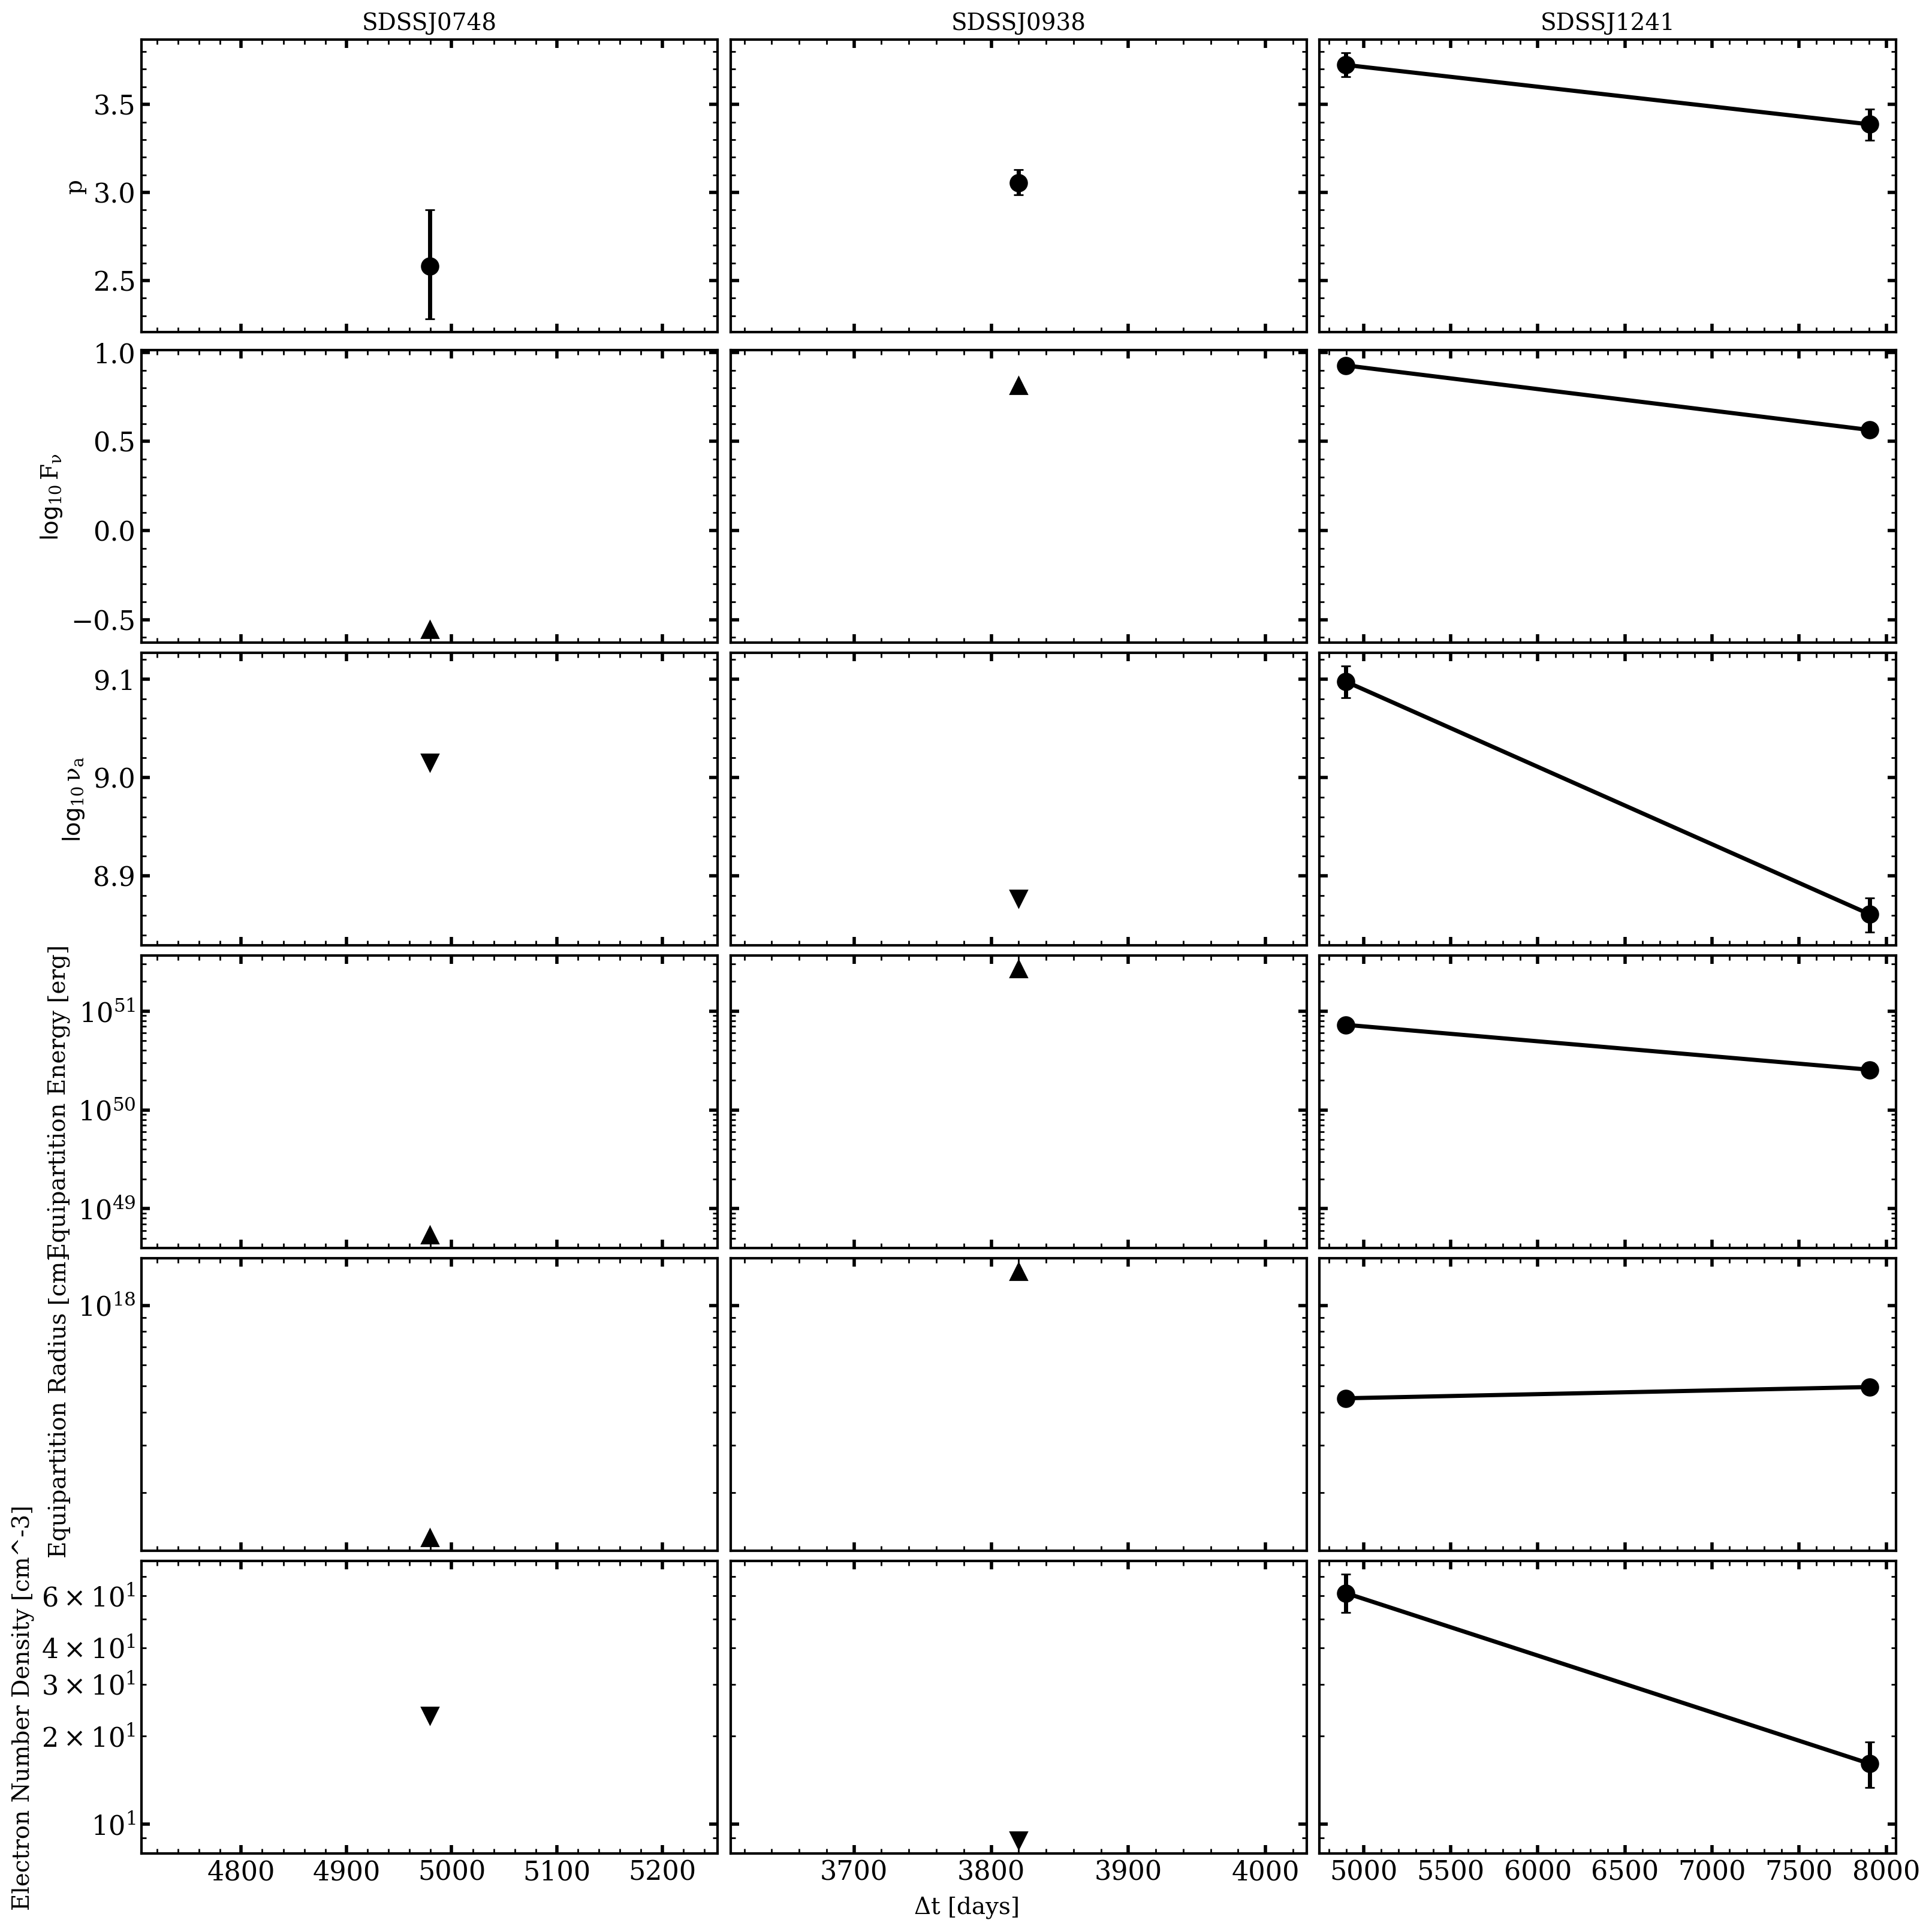

In [6]:
keys = {
    "p" : "p",
    "log_F_nu": r"$\log_{10} F_{\nu}$",
    "log_nu_a": r"$\log_{10} \nu_a$",
    "Eeq" : "Equipartition Energy [erg]",
    "Req" : "Equipartition Radius [cm]",
    "n_e" : "Electron Number Density [cm^-3]"
}

ranges = {
    "Eeq" : (1e48, 1e52),
    "Req" : (1e17, 1e20),
    "p": (2,4),
    "log_F_nu": (0,5),
    "log_nu_a": (6,10),
}

fig, axs = plt.subplots(len(keys),3, sharex="col", sharey="row", figsize=(16,16), layout="constrained")

xvar = "dt"

priors = syncfit.models.B5().prior
ranges = priors | ranges # this will default to the priors but replace them with anything in ranges

label_fs = 14
ms = 10

for idx, (ax1d, (key, label)) in enumerate(zip(axs, keys.items())):
    ax1d[0].set_ylabel(label, fontsize=label_fs)
    for jj, (ax, (name, grp)) in enumerate(zip(ax1d, results_df.groupby("name"))):
        cplot = 'k'

        not_uplim = grp[~grp[key+"_lim"]]
        ax.errorbar(
            not_uplim[xvar], 
            not_uplim[key], 
            yerr=(not_uplim[key+"_lo"], not_uplim[key+"_up"]), 
            marker='o', 
            linestyle='none', 
            color=cplot,
            capsize=3,
            markersize=ms
        )

        uplims = grp[grp[key+"_lim"]]
        if len(uplims) > 0:
            lim_type = uplims[key+"_lim_type"].iloc[0]
            symb = 'v' if lim_type == "upper" else '^'
            
            ax.plot(
                grp.loc[uplims.index, xvar],
                grp.loc[uplims.index, key],
                marker=symb,
                linestyle='none',
                color=cplot,
                markersize=ms
            )

        if not idx:
            ax.set_title(f"{name}", fontsize=label_fs)
        
        grp = grp.reset_index()
        if len(grp) <= 1: continue
        for ii,row in grp.iterrows():

            if ii == 0:
                # just check if the next one is an upperlimit
                hasuplim = row[key+"_lim"] or grp.iloc[ii+1][key+"_lim"]
            elif ii == len(grp)-1:
                hasuplim = row[key+"_lim"] or grp.iloc[ii-1][key+"_lim"]
            else:
                hasuplim = row[key+"_lim"] or grp.iloc[ii-1][key+"_lim"] or grp.iloc[ii+1][key+"_lim"]

            linestyle='-'
            if hasuplim:
                linestyle='--'

            ax.plot(
                grp.iloc[ii-1:ii+1][xvar],
                grp.iloc[ii-1:ii+1][key],
                marker='none',
                linestyle=linestyle,
                color=cplot
            )

        # ax.set_ylim(*ranges[key])
        # ax.set_xscale("log")

axs[-1][0].set_yscale("log")
axs[-2][0].set_yscale("log")
axs[-3][0].set_yscale("log")

fig.supxlabel(r"$\Delta$t [days]", fontsize=label_fs)

fig.savefig("equipartition-results-bootstrap.png", bbox_inches="tight")

# Plot Equipartition Results against literature

In [7]:
def draw_limit_arrow(df, ax, direction, ratio=3, xkey='Req', ykey="n_e", norm_Req=True, **kwargs):
        
    if xkey == "Req" and norm_Req:
        center_xs = df.Req/df.R_s
    else:
        center_xs = df[xkey]
    
    print(len(df))
    
    center_ys = df[ykey]
        
    if direction == "left":
        u = -1*np.ones(len(df))
        v = np.zeros(len(df))
        
    elif direction == "right":
        u = np.ones(len(df))
        v = np.zeros(len(df))
    
    elif direction == "up":
        u = np.zeros(len(df))
        v = np.ones(len(df))
        
    elif direction == "down":
        u = np.zeros(len(df))
        v = -1*np.ones(len(df))
    
    else:
        raise Exception()
    
    ax.quiver(
        center_xs,
        center_ys,
        u,
        v,
        width=0.002,
        headwidth=5,
        scale_units="inches",
        **kwargs
    )

In [8]:
lit = pd.read_csv("lit_sed_params.csv", comment="#")

# gamma(F_p_mJy, nu_p, z, d_L, t_d, eta=1, f_V=1, f_A=1)
lit["gamma"] = Gamma(
    F_p_mJy = lit.Fp_mJy, 
    nu_p = lit.nu_a*1e9, 
    z = lit.z, 
    d_L = cosmo.luminosity_distance(lit.z).to("cm").value, 
    t_d = lit.t
)

lit.gamma = lit.gamma.apply(lambda v : v if v > 1 else 1)

# Req(p, F_p_mJy, nu_p, z, d_L, epsilon_e=0.1, gamma=1, f_V=1, f_A=1):
lit["Req"] = [Req(
    p = r.p, 
    F_p_mJy = r.Fp_mJy, 
    nu_p = r.nu_a*1e9, 
    z = r.z, 
    d_L = cosmo.luminosity_distance(r.z).to("cm").value,
    gamma = r.gamma,
    epsilon_e = r.epsilon_e,
    epsilon_B = r.epsilon_B,
    nu_m = r.nu_m if r.nu_m > 0 else None
) for _, r in lit.iterrows()]

# n_e(F_p_mJy, d_L, nu_p, z, R_17, f_A=1, eta=1, emitting_region_width_fraction=0.1)
lit["n_e"] = n_e(
    p = lit.p,
    F_p_mJy = lit.Fp_mJy, 
    d_L = cosmo.luminosity_distance(lit.z).to("cm").value, 
    nu_p = lit.nu_a*1e9, 
    z = lit.z,
    R_17 = lit.Req/1e17,
    gamma = lit.gamma
)

# Eeq(p, F_p_mJy, nu_p, z, d_L, epsilon_e=0.1, epsilon_B=None, gamma=1, f_V=0.36, f_A=1, nu_m=None)
lit["Eeq"] = [Eeq(
    p = r.p, 
    F_p_mJy = r.Fp_mJy, 
    nu_p = r.nu_a*1e9, 
    z = r.z, 
    d_L = cosmo.luminosity_distance(r.z).to("cm").value,
    gamma = r.gamma,
    epsilon_e = r.epsilon_e,
    epsilon_B = r.epsilon_B,
) for _, r in lit.iterrows()]

# beta
lit["beta"] = beta(
    t = (lit.t.values*u.day).to(u.s),
    z = lit.z,
    R = lit.Req
)

In [9]:
# Add the ASASSN-19bt profile from Collin
with open("ASASSN19bt_fit_params.json", "r") as f:
    asassn19bt = pd.DataFrame([eval(line) for line in f.readlines()])

asassn19bt_merge = pd.DataFrame(
    dict(
        Name = "ASASSN-19bt",
        t = asassn19bt.t,
        Req = asassn19bt.R_t,
        n_e = asassn19bt.Next_t,
        Eeq = asassn19bt.E_t
    )
)


lit = pd.concat([lit, asassn19bt_merge])
lit = lit[lit.Name != "CNSSJ0019+00"]

In [10]:
lit

,Name,t,p,epsilon_e,epsilon_B,nu_a,nu_a_error,nu_m,nu_m_error,Fp_mJy,Fp_mJy_error,dist_Mpc,z,gamma,Req,n_e,Eeq,beta
4,ASASSN-14li,128,3.0,0.1,0.1,16.80,0.00,-99.99,-99.99,1.91,0.00,90.0,0.0206,1.0,7.920084e+15,5190.209138,4.653733e+47,0.023800
5,ASASSN-14li,143,3.0,0.1,0.1,8.20,0.10,-99.99,-99.99,1.76,0.01,90.0,0.0206,1.0,1.560988e+16,1257.975090,8.635711e+47,0.041238
6,ASASSN-14li,207,3.0,0.1,0.1,4.37,0.20,-99.99,-99.99,1.23,0.03,90.0,0.0206,1.0,2.471856e+16,385.271333,1.050179e+48,0.044937
7,ASASSN-14li,246,3.0,0.1,0.1,4.00,0.06,-99.99,-99.99,1.14,0.01,90.0,0.0206,1.0,2.605031e+16,327.998024,1.046495e+48,0.040054
8,ASASSN-14li,304,3.0,0.1,0.1,2.55,0.06,-99.99,-99.99,0.94,0.02,90.0,0.0206,1.0,3.729485e+16,138.825379,1.299699e+48,0.046110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2,ASASSN-19bt,132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.112582e+16,183.128343,5.200673e+47,NaN
3,ASASSN-19bt,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.348447e+16,58.589324,1.450233e+48,NaN
4,ASASSN-19bt,457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.461083e+16,101.537162,8.229193e+48,NaN
5,ASASSN-19bt,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.275907e+17,24.148662,1.498202e+49,NaN


In [11]:
# update the Sw J1644+57 equipartition energies directly from Eftekhari+2018

j1644_energy = np.loadtxt(io.StringIO("""
50.27
50.48
50.61
50.63
50.93
51.08
51.23
51.40
51.43
51.50
51.55
51.53
51.57
51.54
51.51
51.49
51.44
51.59
51.41
51.48
51.40
51.31
51.49
"""))

j1644_t = np.loadtxt(io.StringIO("""
5
10
15
22
36
51
68
97
126
161
197
216
244
301
390
457
582
645
791
1030
1100
1362
1894
"""))

# lit[lit.Name == "SwJ1644+57"]
updated_from_lit = pd.DataFrame({"updated_eeq":10**j1644_energy, "updated_t":j1644_t})

matching_indices = lit[(lit.Name == "SwJ1644+57")*(lit.t.isin(updated_from_lit.updated_t))].index
lit.loc[matching_indices, 'Eeq'] = lit.loc[matching_indices, 't'].map(
    updated_from_lit.set_index('updated_t')['updated_eeq']
)

lit[lit.Name == "SwJ1644+57"]

,Name,t,p,epsilon_e,epsilon_B,nu_a,nu_a_error,nu_m,nu_m_error,Fp_mJy,Fp_mJy_error,dist_Mpc,z,gamma,Req,n_e,Eeq,beta
29,SwJ1644+57,5,2.5,0.1,0.001,51.286138,20.665872,398.107171,0.000000,19.751995,21.215,1900.0,0.354,2.184140,6.993878e+16,131.874570,1.862087e+50,0.879691
30,SwJ1644+57,10,2.5,0.1,0.001,12.882496,2.373043,213.796209,123.070991,11.106425,3.090,1900.0,0.354,2.935658,2.482063e+17,0.812266,3.019952e+50,0.928442
31,SwJ1644+57,15,2.5,0.1,0.001,9.549926,1.869109,141.253754,60.171026,9.979705,2.375,1900.0,0.354,2.627676,3.000032e+17,1.133627,4.073803e+50,0.912701
32,SwJ1644+57,22,2.5,0.1,0.001,11.220185,0.387531,57.543994,11.262495,8.519851,0.675,1900.0,0.354,1.695412,1.888701e+17,69.847091,4.265795e+50,0.817775
33,SwJ1644+57,36,2.5,0.1,0.001,6.760830,0.544859,70.794578,0.000000,10.448713,1.030,1900.0,0.354,1.832964,3.588550e+17,12.047960,8.511380e+50,0.838989
34,SwJ1644+57,51,2.5,0.1,0.001,8.128305,1.029386,69.183097,0.000000,12.329237,2.095,1900.0,0.354,1.328303,2.787666e+17,344.811744,1.202264e+51,0.740751
35,SwJ1644+57,68,2.5,0.1,0.001,8.912509,0.307827,51.286138,0.000000,15.229410,1.210,1900.0,0.354,1.089050,2.804344e+17,3145.013241,1.698244e+51,0.683122
36,SwJ1644+57,97,2.5,0.1,0.001,7.943282,0.548703,30.902954,3.913618,17.491479,2.755,1900.0,0.354,1.000000,3.885095e+17,2655.683317,2.511886e+51,0.676762
37,SwJ1644+57,126,2.5,0.1,0.001,8.128305,0.467903,21.379621,1.476852,16.143394,2.410,1900.0,0.354,1.000000,3.655555e+17,2830.848705,2.691535e+51,0.602636
38,SwJ1644+57,161,2.5,0.1,0.001,7.244360,0.667230,12.882496,1.779783,15.582227,7.990,1900.0,0.354,1.000000,4.033644e+17,2266.371894,3.162278e+51,0.567034


3    23.497634
Name: n_e, dtype: float64
1
1
2    8.811637
Name: n_e, dtype: float64
1
1
[(269146.3641210154, 269257.22783345846), (296368.62579824193, 296426.41622620303)]
1    61.392840
0    16.088646
Name: n_e, dtype: float64


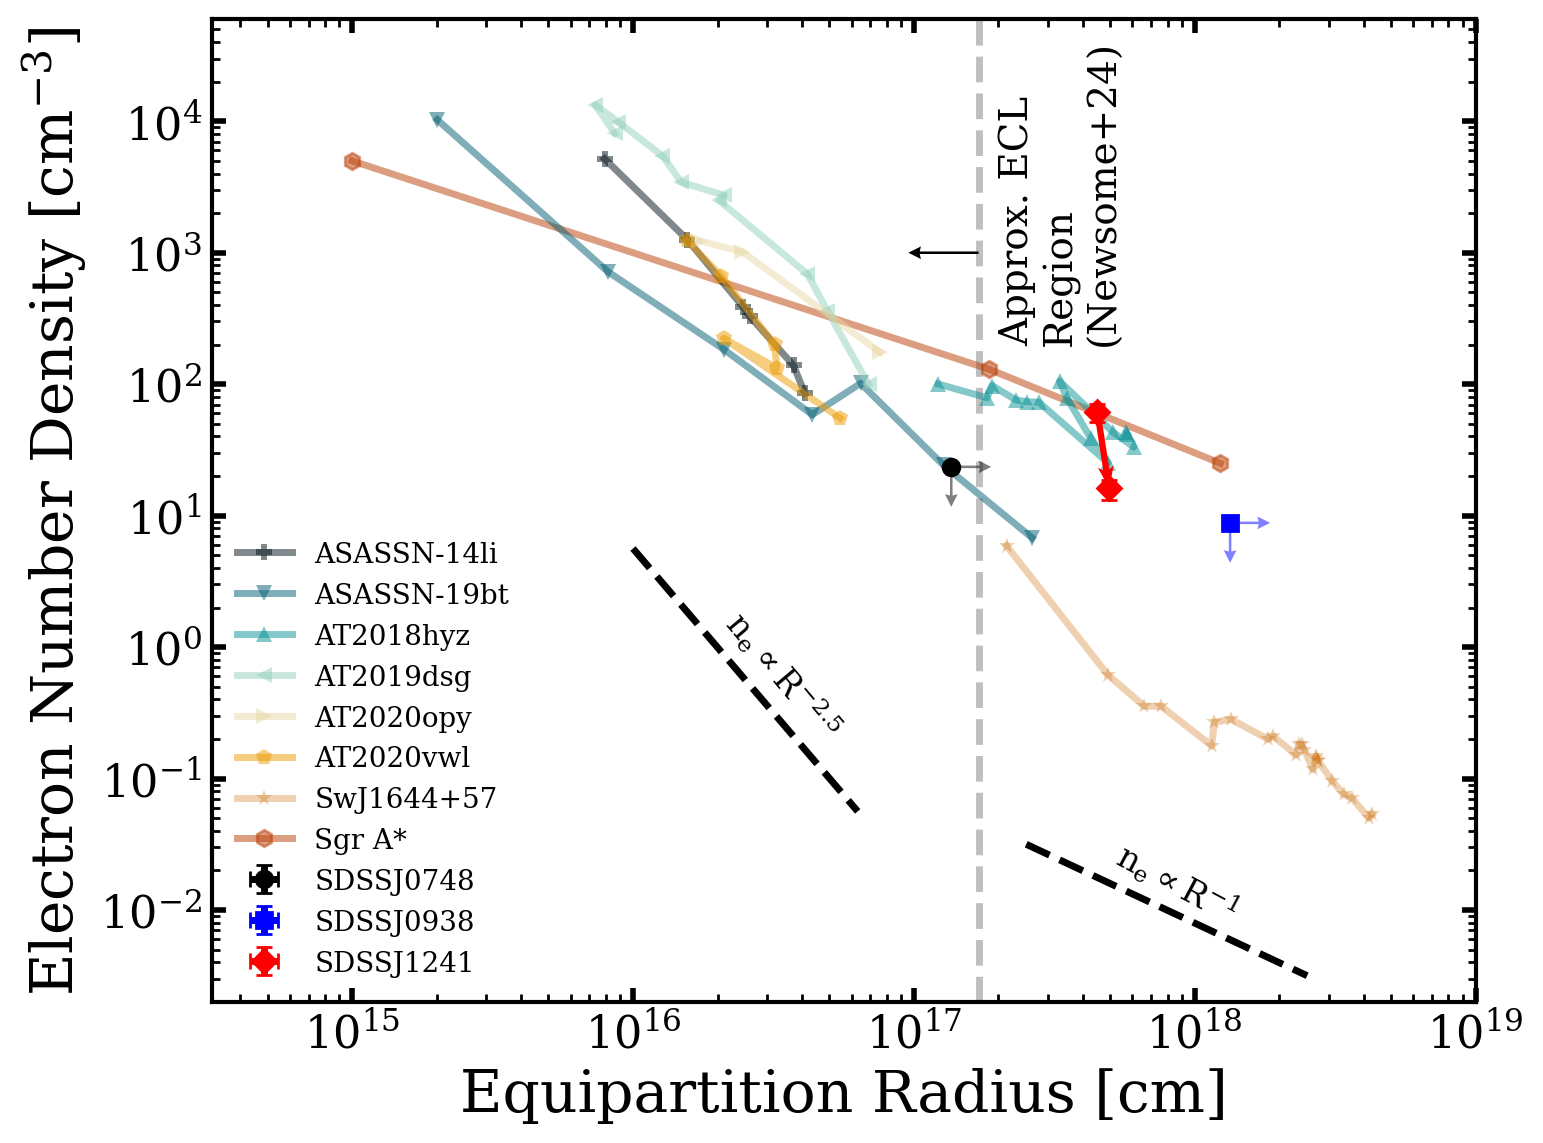

In [12]:
lit_density_profiles = pd.read_csv("density_profile_litTDEs.csv", index_col=0)
bh_masses = pd.read_csv("bh_masses_host.txt", sep="\t")
bh_masses["R_s"] = R_s((10**bh_masses.bhmass.to_numpy())*c.M_sun)

SCALE = 5

ecle_zorder = 100
tde_zorder = 50
bh_zorder = 25
fill_zorder = 1

symbs = ["o", "s", "D", "P", "v", "^", "<", ">", "p", "*", "h", "d", "x", "H"]
symbs_idx = 0

name_map = {
    "SwJ1644+57" : "Sw J1644+57",
    #"CNSSJ0019+00" : "CNSS J0019+00"
}

# now plot the n_e values on a n_e vs. radius

fig, ax = plt.subplots(figsize=(8,6))

color_dict = {
    "SDSSJ1241" : "red",
    "SDSSJ0938" : "blue",
    "SDSSJ0748" : "black"
}

names_to_plot = {"SDSSJ1241", "SDSSJ0748", "SDSSJ0938"}


ax.set_xscale("log")
ax.set_yscale("log")

results_df["Req_Rs_err_lo"] = results_df.Req/results_df.R_s * np.sqrt((results_df.R_s_err/results_df.R_s)**2 + (results_df.Req_lo/results_df.Req)**2)
results_df["Req_Rs_err_up"] = results_df.Req/results_df.R_s * np.sqrt((results_df.R_s_err/results_df.R_s)**2 + (results_df.Req_up/results_df.Req)**2)

# add the ECLE density profiles
for name, grp in results_df.groupby("name"):
    
    if name not in names_to_plot: continue

    grp = grp.sort_values("mjd")
    
    yerr = [(0,0)]*len(grp)
    if len(grp[~grp.n_e_lim]) > 0:
        yerr = [(r.n_e_up, r.n_e_lo) if not r.n_e_lim else (0, 0) for _,r in grp.iterrows()]
        
    xerr = [(0,0)]*len(grp)
    if len(grp[~grp.Req_lim]) > 0:
        xerr = [
            (
                r.Req_Rs_err_lo, 
                r.Req_Rs_err_up
            ) if not r.Req_lim 
            else (0, 0) 
            for _,r in grp.iterrows()
        ]
        print(xerr)
    
    ax.errorbar(
        # grp.Req/grp.R_s,
        grp.Req.values,
        grp.n_e,
        yerr = list(zip(*yerr)),
        xerr = list(zip(*xerr)),
        color = color_dict[name],
        label = name,
        linestyle = "none",
        marker = symbs[symbs_idx],
        capsize = 3,
        zorder = ecle_zorder
    )

    if len(grp) > 1:
        # x = (grp.Req/grp.R_s).values
        x = grp.Req.values
        y = grp.n_e.values
        ax.quiver(x[:-1], y[:-1], x[1:]-x[:-1], y[1:]-y[:-1], scale_units='xy', angles='xy', scale=1, 
                  width=0.005, headlength=3.5, headaxislength=3, headwidth=2.5, zorder=100, color="red")
    
    print(grp.n_e)
    
    symbs_idx += 1
    
    r_lim = grp[grp.Req_lim]
    if not len(r_lim): continue
    direction = "left" if r_lim.Req_lim_type.iloc[0] == "upper" else "right"
    draw_limit_arrow(r_lim, ax, direction, color=color_dict[name], alpha=0.5, scale=SCALE, zorder=ecle_zorder, norm_Req=False)
    
    ne_lim = grp[grp.n_e_lim]
    direction = "down" if r_lim.n_e_lim_type.iloc[0] == "upper" else "up"
    draw_limit_arrow(ne_lim, ax, direction, color=color_dict[name], alpha=0.5, scale=SCALE, zorder=ecle_zorder, norm_Req=False)

# add literature Density profiles
for name, grp in lit.groupby("Name"):

    grp = grp.sort_values("t")
    
    if name in name_map:
        # then just plot the literature ones 
        # some of these are more complex to calculate than others so we will defer to the
        # literature values
        lit_densities = lit_density_profiles[lit_density_profiles.name == name_map[name]]
        
        ax.plot(
            lit_densities["R"], # ["R/Rs"]
            lit_densities.n,
            marker = symbs[symbs_idx],
            linestyle = '-',
            alpha=0.3,
            label=name,
            zorder = tde_zorder,
            mew=0
        )
        
        symbs_idx += 1
        
        continue
    
    r_s = bh_masses[bh_masses.name == name].R_s.values[0]
    ax.plot(
        grp.Req.values,#/r_s,
        grp.n_e,
        marker = symbs[symbs_idx],
        linestyle = '-',
        alpha=0.5,
        label=name,
        zorder = tde_zorder,
        mew=0
    )
    symbs_idx += 1

# add Sgr A* and M87*
for bh,kwargs in zip(['Sgr A*'], [{}]):
    lit_densities = lit_density_profiles[lit_density_profiles.name == bh]
        
    ax.plot(
        lit_densities["R"], # ["R/Rs"]
        lit_densities.n,
        marker = symbs[symbs_idx],
        linestyle = '-',
        alpha=0.5,
        label=bh,
        zorder=bh_zorder,
        **kwargs
    )
    
    symbs_idx += 1
    
ax.set_ylabel(r"Electron Number Density [cm$^{-3}$]", fontsize=21)
ax.set_xlabel(r"Equipartition Radius [cm]", fontsize=21)

ax.set_xlim(10**14.5, 10**19)
ax.set_ylim(2e-3, 6e4)

# plot some literature values for the [Fe X] radius of different ECLEs
ax.axvline(
    #np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]), 
    16.99e16, 
    alpha=0.25, 
    zorder = fill_zorder,
    linestyle = "--",
    color = "k"
)

ax.text(
    #np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]) + 1e5,
    2e17,
    2e2,
    "Approx. ECL\nRegion\n(Newsome+24)",
    rotation=90,
    fontsize=14,
    verticalalignment="bottom",
    horizontalalignment="left"
)

ax.quiver(
    #np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]),
    16.99e16,
    1e3,
    -16.99e16, #np.mean([4.23e16 / R_s(5e5*c.M_sun), 16.99e16 / R_s(2e6*c.M_sun)]) * (1-1/10),
    1e3,
    width=0.002,
    headwidth=5,
    scale_units="inches",
    **kwargs
)

R = np.logspace(16, 16.8)
k = 1/(10**16.3)**-2.5
ax.plot(R, k*R**-2.5, linestyle='--', color='k')
ax.text(2e16, 2e-1, r"$n_e \propto R^{-2.5}$", rotation=-50, fontsize=12)

R = np.logspace(17.4, 18.4) #np.logspace(5.8, np.log10(3e6))
k = 1/(10**15.9)**-1
ax.plot(R, k*R**-1, linestyle='--', color='k')
ax.text(5e17, 8e-3, r"$n_e \propto R^{-1}$", rotation=-28, fontsize=12)

ax.legend(loc="lower left", fontsize=10, ncols=1)

fig.savefig("ecle-density-profile-w-reference-labels.png")

[7905. 4897.]


/tmp/ipykernel_2986006/1882261056.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grp['t'] = dt


[3820.]
1


/tmp/ipykernel_2986006/1882261056.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grp['t'] = dt
Names have the same score! Just using the existing default_name
/tmp/ipykernel_2986006/1882261056.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  grp['t'] = dt


[4979.]
1


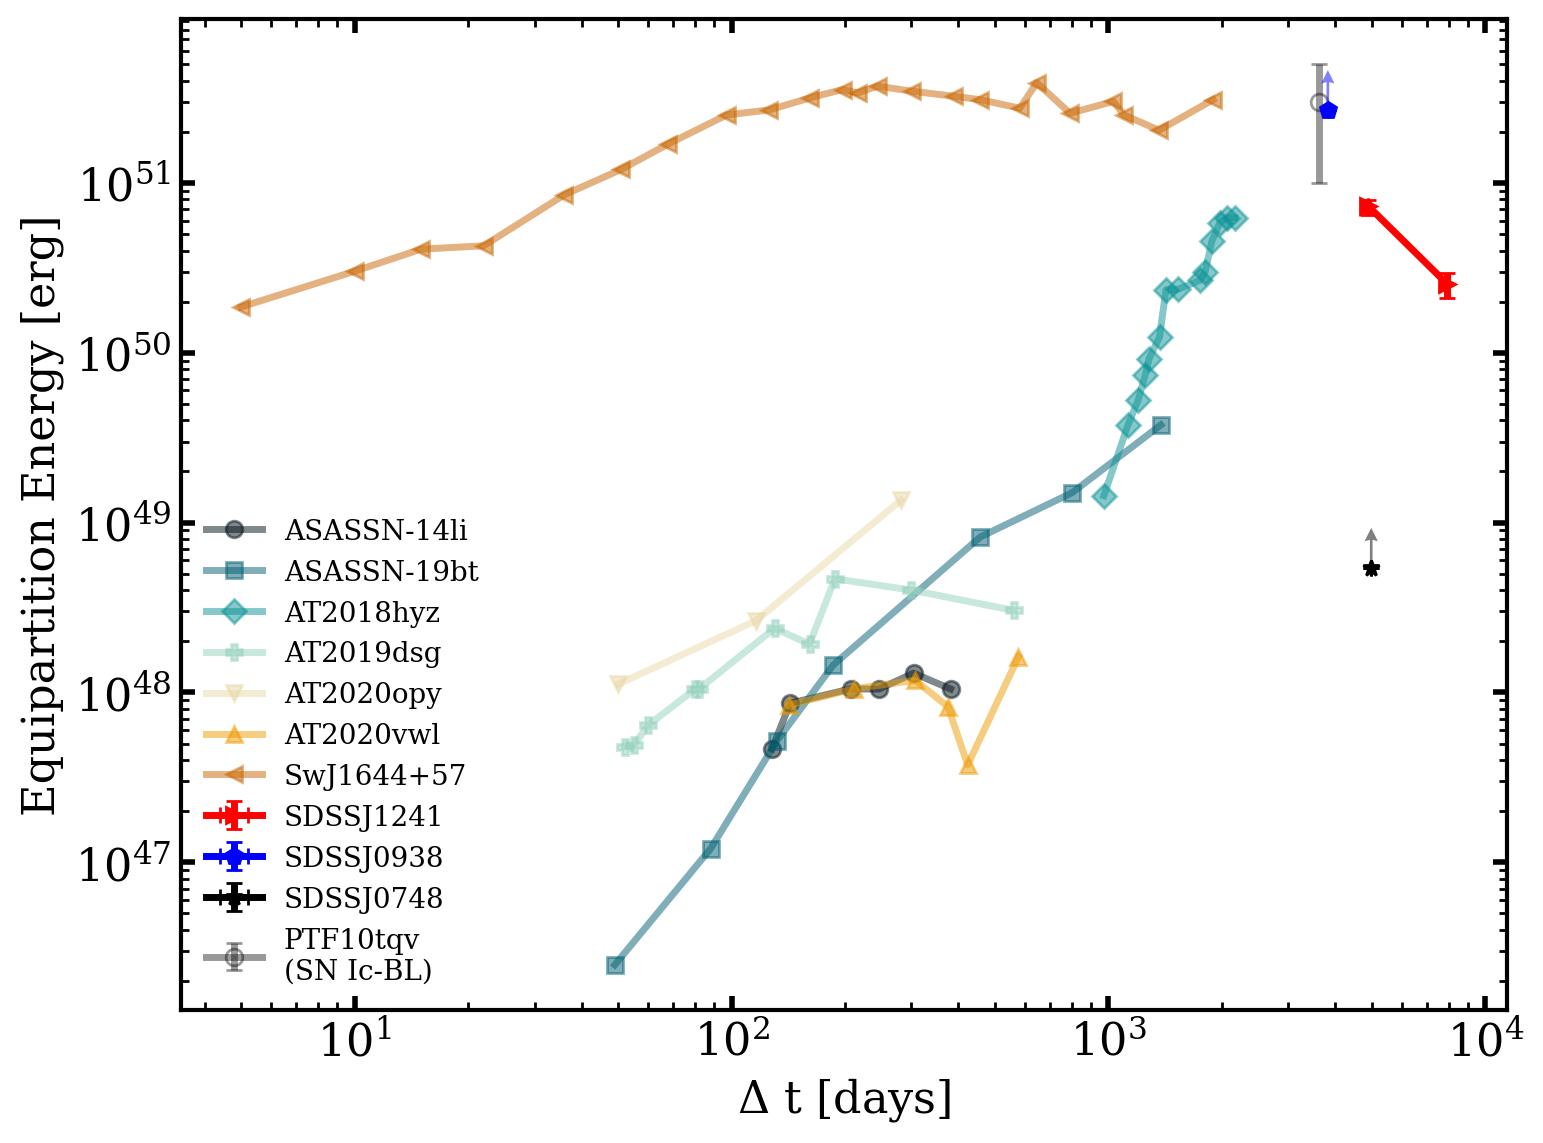

In [19]:
fig, ax = plt.subplots(figsize=(8,6))

symbs_idx = 0
label_idx = 0
names = []

xkey = "t"
        
for name, grp in lit.groupby("Name"):   

    grp = grp.sort_values("t")
    
    ax.errorbar(
        grp[xkey], #[label_idx],
        grp.Eeq,
        marker = symbs[symbs_idx],
        linestyle = "-",
        label = name,
        zorder = -100,
        alpha=0.5,
        # mew=0,
        # color = color_dict[name]
    )
    
    # ax.axvline(label_idx-0.5, color='k', alpha=0.1)
    
    symbs_idx += 1
    label_idx += 1
    names.append(name)
    
# add the ECLE density profiles
for name in ["SDSS_J1241", "SDSS_J0938", "SDSS_J0748"]:
    
    label_name = name.replace("_", "")
    grp = results_df[results_df.name == label_name]
    
    # if name not in names_to_plot: continue
    if xkey == "t":
        meta = db.get_meta(names=name, query_private=True)
        dd = meta[0].get_discovery_date().mjd
        dt = grp.mjd.values.astype(float) - dd
        print(dt)
        grp['t'] = dt
        
    yerr = [(0,0)]*len(grp)
    if len(grp[~grp.Eeq_lim]) > 0:
        yerr = [(r.Eeq_up, r.Eeq_lo) if not r.Eeq_lim else (0, 0) for _,r in grp.iterrows()]
        
    xerr = [(0,0)]*len(grp)
    if xkey != "t" and len(grp[~grp.Req_lim]) > 0:
        xerr = [(r.Req_up, r.Req_lo) if not r.Req_lim else (0, 0) for _,r in grp.iterrows()]
    
    ax.errorbar(
        grp[xkey],
        grp.Eeq,
        yerr = list(zip(*yerr)),
        xerr = list(zip(*xerr)),
        color = color_dict[label_name],
        label = label_name,
        linestyle = "-",
        marker = symbs[symbs_idx],
        capsize = 3,
        zorder = ecle_zorder
    )
    
    
    symbs_idx += 1
    
    if xkey == "Req":
        r_lim = grp[grp.Req_lim]
        if not len(r_lim): continue
        direction = "left" if r_lim.Req_lim_type.iloc[0] == "upper" else "right"
        draw_limit_arrow(r_lim, ax, direction, color=color_dict[label_name], alpha=0.5, scale=SCALE, zorder=ecle_zorder, xkey=xkey, ykey="Eeq", norm_Req=False)
    elif xkey == "t":
        #@draw_limit_arrow(grp, ax, "right", color=color_dict[label_name], alpha=0.5, scale=SCALE, zorder=ecle_zorder, xkey=xkey, ykey="Eeq", norm_Req=False)
        pass
    else:
        raise ValueError()
    
    E_lim = grp[grp.Eeq_lim]
    if not len(E_lim): continue
    direction = "down" if E_lim.Eeq_lim_type.iloc[0] == "upper" else "up"
    draw_limit_arrow(E_lim, ax, direction, color=color_dict[label_name], alpha=0.5, scale=SCALE, zorder=ecle_zorder, xkey=xkey, ykey="Eeq", norm_Req=False)


# PTF10tqv afterglow (Schroeder+25)
E_err = (10**51.7 - 10**51)/2
E_10tqv = 10**51 + E_err
ax.errorbar(
    [3623], 
    [E_10tqv],
    yerr = [E_err],
    marker = "o",
    capsize=3,
    markerfacecolor = "none",
    color = "k",
    label = "PTF10tqv\n(SN Ic-BL)",
    alpha = 0.4
)
    
ax.set_yscale("log")
ax.set_xscale("log")

ax.set_xlabel(r"$\Delta$ t [days]", fontsize=16)
ax.set_ylabel("Equipartition Energy [erg]", fontsize=16)

ax.legend(fontsize=10, frameon=False, ncols=1, fancybox=False)

fig.savefig("ecle-energy-comparison.png", bbox_inches="tight")

[[4.65373265e+47]
 [1.29969906e+48]]
[[2.49075172e+46]
 [3.75601953e+49]]
[[1.43937495e+49]
 [6.24074840e+50]]
[[4.80523801e+47]
 [4.66959866e+48]]
[[1.11748919e+48]
 [1.35018002e+49]]
[[3.74054284e+47]
 [1.61959215e+48]]
[[1.86208714e+50]
 [3.89045145e+51]]
['lower']
1
1
['lower']
1
1


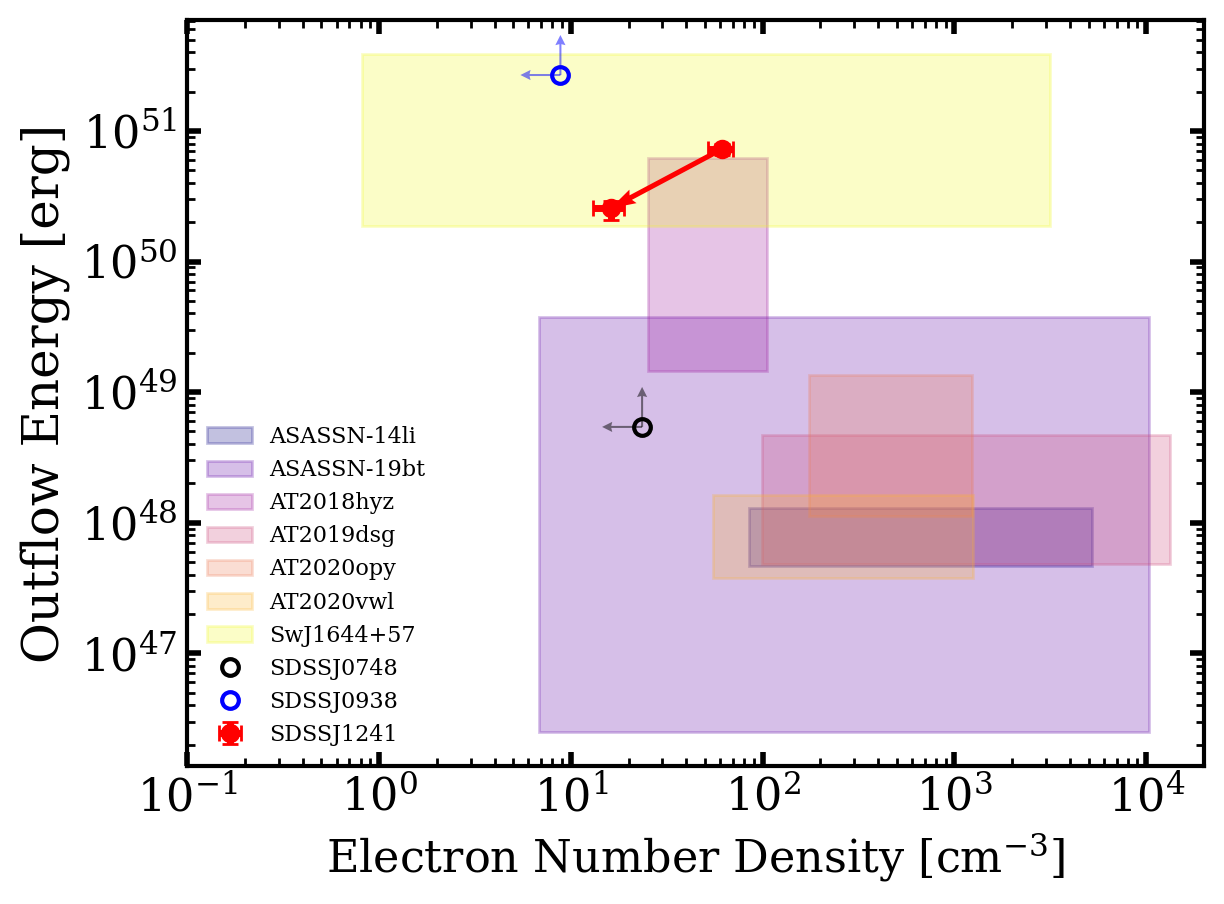

In [14]:
from matplotlib.patches import Rectangle
fig, ax = plt.subplots()

symbs_idx = 0
label_idx = 0
names = []
names_to_plot = ["SDSSJ1241", "SDSSJ0938", "SDSSJ0748"]

cmap = plt.cm.plasma
colors = cmap(np.linspace(0,1, len(lit.Name.unique())))
        
for (name, grp), col in zip(lit.groupby("Name"), colors):   
    print(np.array(list(zip([grp.Eeq.min()], [grp.Eeq.max()]))).T)
    # ax.errorbar(
    #     grp.n_e.median(), #[label_idx],
    #     grp.Eeq.median(),
    #     yerr = np.array(list(zip([grp.Eeq.median()-grp.Eeq.min()], [grp.Eeq.max()-grp.Eeq.median()]))).T,
    #     xerr = np.array(list(zip([grp.n_e.median()-grp.n_e.min()], [grp.n_e.max()-grp.n_e.median()]))).T,
    #     marker = "none",
    #     linestyle = "none",
    #     label = name,
    #     zorder = -100,
    #     alpha=0.5,
    #     # mew=0,
    #     capsize=6
    # )

    dx, dy = grp.n_e.max() - grp.n_e.min(), grp.Eeq.max() - grp.Eeq.min()
    lower_left_coord = grp.n_e.min(), grp.Eeq.min()
    #print(name, ctr_x, ctr_y, dx, dy, lower_left_coord)
    #print(col)
    rect = Rectangle(
        lower_left_coord,
        dx, dy,
        zorder = -100,
        alpha = 0.25,
        label = name,
        color = col
        
    )
    ax.add_patch(rect)
    # ax.axvline(label_idx-0.5, color='k', alpha=0.1)
    
    symbs_idx += 1
    label_idx += 1
    names.append(name)
    
# ax.axvline(label_idx-0.5, color='k')
    
for name, grp in results_df.groupby("name"):

    grp = grp.sort_values("mjd")        
    lims = grp[grp.log_F_nu_lim]
    nolim = grp[~grp.log_F_nu_lim]

    if len(nolim) > 0:
        ax.errorbar(
            nolim.n_e.values, #np.ones(len(nolim))*label_idx,
            nolim.Eeq.values,
            yerr = nolim[["Eeq_up", "Eeq_lo"]].values.T,
            xerr = nolim[["n_e_up", "n_e_lo"]].values.T,
            linestyle = "none",
            marker = "o",
            label = name,
            color = color_dict[name]
        )

        if len(grp) > 1:
            x = nolim.n_e.values
            y = nolim.Eeq.values
            ax.quiver(x[:-1], y[:-1], x[1:]-x[:-1], y[1:]-y[:-1], scale_units='xy', angles='xy', scale=1, 
                      width=0.005, headlength=5, headaxislength=4.5, headwidth=3, zorder=100, color="red")
        
    if len(lims) > 0:
        ax.plot(
            lims.n_e.values, #np.ones(len(lims))*label_idx,
            lims.Eeq.values,
            linestyle = "none",
            marker = "o",
            markerfacecolor='none',
            markeredgewidth=1.5, 
            markeredgecolor=color_dict[name],
            label = name
        )
        print(lims.Req_lim_type.values)
        direction = "left" if lims.n_e_lim_type.values[0] == "upper" else "right"
        draw_limit_arrow(lims, ax, direction, color=color_dict[name], alpha=0.5, xkey="n_e", ykey="Eeq", scale=SCALE, zorder=ecle_zorder)

        direction = "down" if lims.Eeq_lim_type.values[0] == "upper" else "up"
        draw_limit_arrow(lims, ax, direction, color=color_dict[name], alpha=0.5, xkey="n_e", ykey="Eeq", scale=SCALE, zorder=ecle_zorder)
        
    symbs_idx += 1
    label_idx += 1
    
    names.append(name)
    
# ax.set_xlabel(r"Object Name")
ax.set_ylabel(r"Outflow Energy [erg]", fontsize=18)
ax.set_xlabel(r"Electron Number Density [cm$^{-3}$]")

ax.set_yscale("log")
ax.set_xscale("log")
# ax.set_xscale("log")
# ax.set_xticks(list(range(label_idx)))
# ax.set_xticklabels(names, rotation=45, fontsize=14, horizontalalignment="right")
# ax.legend(loc="best", fontsize=6, ncols=2);

ax.set_xlim(1e-1, 2e4)

ax.legend(fontsize=8)

fig.savefig("ecle-energy-ne-comparison.png")

# calcualte the outflow velocity

In [15]:
j1241_res = results_df[results_df.name == "SDSSJ1241"]

def beta(dt, R, z):
    return ((1 + c.c*dt / (R*(1+z)))**-1).cgs

R = np.diff(j1241_res.Req) * u.cm
dt = np.diff(j1241_res.mjd.astype(float)) * u.day
beta(dt, R, db.get_meta(names="SDSS_J1241", query_private=True)[0].get_redshift())

<Quantity [0.00607601]>

# get the derived parameters table

In [16]:
results_df

,name,mjd,p,p_up,p_lo,p_chain,log_F_nu,log_F_nu_up,log_F_nu_lo,log_F_nu_chain,...,Req_lim,Req_lim_type,Eeq_chain,Eeq,Eeq_up,Eeq_lo,Eeq_lim,Eeq_lim_type,Req_Rs_err_lo,Req_Rs_err_up
0,SDSSJ1241,60967.0,3.386910,0.087268,0.089066,"[3.2679121079218025, 3.3539253960752884, 3.392...",0.564602,0.016208,0.016039,"[0.5434131282223658, 0.5730810091666221, 0.579...",...,False,lower,"[1.9642916122965087e+50, 2.4571227321785887e+5...",2.554085e+50,4.569909e+49,3.766042e+49,False,lower,296368.625798,296426.416226
1,SDSSJ1241,57959.0,3.724464,0.069052,0.068371,"[3.621524851919936, 3.689507618302295, 3.70800...",0.926873,0.011062,0.010923,"[0.9245284412643235, 0.9359265452152056, 0.944...",...,False,lower,"[6.338653831685806e+50, 7.315397848104725e+50,...",7.275337e+50,7.735727e+49,7.014126e+49,False,lower,269146.364121,269257.227833
2,SDSSJ0938,57912.0,3.053439,0.076760,0.068440,"[3.011181432239487, 2.9513329994447255, 3.1359...",0.814829,0.000000,0.000000,"[1.3183299648733493, 1.6839582654785334, 0.859...",...,True,lower,"[2.9836472967969006e+52, 1.9271179612001546e+5...",2.681457e+51,0.000000e+00,0.000000e+00,True,lower,84440.717962,84440.717962
3,SDSSJ0748,57914.0,2.580505,0.322214,0.298702,"[2.9580353051773542, 2.793411381802714, 2.4356...",-0.555978,0.000000,0.000000,"[1.7879441414968558, 1.5935250585102143, 1.390...",...,True,lower,"[1.4486738997240476e+54, 9.059308218036231e+53...",5.411044e+48,0.000000e+00,0.000000e+00,True,lower,85075.141932,85075.141932


In [17]:
basecolnames = ["p", "log_F_nu", "log_nu_a", "n_e", "Req", "Eeq"]

dflatex_dict = {
    c:[] for c in basecolnames
}

def parse(val):
    base, power = val.split("e")
    if int(power) == 0:
        return base
    return f"{base}\\times 10^{{{int(power)}}}"

for _, row in results_df.iterrows():
    print(row["name"], row["mjd"])
    for basecolname in basecolnames:
        print(
            row[basecolname],
            row[basecolname+"_up"],
            row[basecolname+"_lo"],
            row[basecolname+"_lim"],
            row[basecolname+"_lim_type"]
        )

        if row[basecolname+"_lim"]:
            # then this should be a 3 sigma limit displayed in the table
            if row[basecolname+"_lim_type"] == "upper":
                presymb = "<"
            else:
                presymb = ">"
            dflatex_dict[basecolname].append(f"${presymb}{parse(f'{row[basecolname]:.2e}')}$")
            
        else:
            dflatex_dict[basecolname].append(f"${row[basecolname]:.2e}^{{+{row[basecolname+"_up"]:.2e}}}_{{-{row[basecolname+"_lo"]:.2e}}}$")

dflatex_dict["name"] = results_df.name
dflatex_dict["mjd"] = results_df.mjd

SDSSJ1241 60967.0
3.3869103397078284 0.08726832243794114 0.08906567900159823 False upper
0.5646016529091378 0.016208409680403824 0.01603896510516367 False lower
8.861037499260393 0.01625997955795988 0.018336732935402722 False upper
16.088646361089474 3.0076983533769663 2.7174423986753045 False upper
4.9573238757419315e+17 1.6503604359571328e+16 1.5338648500111616e+16 False lower
2.5540854951227643e+50 4.5699090469820367e+49 3.7660416705865173e+49 False lower
SDSSJ1241 57959.0
3.7244635171891587 0.0690520122270839 0.06837069800584672 False upper
0.9268730880075928 0.011062304867991424 0.010923241998365807 False lower
9.097437045053924 0.015569975385986368 0.016762419343800516 False upper
61.39284049415572 9.7055332183143 8.712239770922018 False upper
4.500181226742076e+17 1.7921821130747392e+16 1.6017468353613056e+16 False lower
7.2753372528617636e+50 7.735726680363481e+49 7.014126386512854e+49 False lower
SDSSJ0938 57912.0
3.0534387777667646 0.07675963248251527 0.06844039769825505 Fals

In [18]:
df = pd.DataFrame(dflatex_dict)
print(df[["name", "mjd", "p", "log_F_nu", "log_nu_a", "n_e", "Req", "Eeq"]].to_latex(index=False))

\begin{tabular}{llllllll}
\toprule
name & mjd & p & log_F_nu & log_nu_a & n_e & Req & Eeq \\
\midrule
SDSSJ1241 & 60967.0 & $3.39e+00^{+8.73e-02}_{-8.91e-02}$ & $5.65e-01^{+1.62e-02}_{-1.60e-02}$ & $8.86e+00^{+1.63e-02}_{-1.83e-02}$ & $1.61e+01^{+3.01e+00}_{-2.72e+00}$ & $4.96e+17^{+1.65e+16}_{-1.53e+16}$ & $2.55e+50^{+4.57e+49}_{-3.77e+49}$ \\
SDSSJ1241 & 57959.0 & $3.72e+00^{+6.91e-02}_{-6.84e-02}$ & $9.27e-01^{+1.11e-02}_{-1.09e-02}$ & $9.10e+00^{+1.56e-02}_{-1.68e-02}$ & $6.14e+01^{+9.71e+00}_{-8.71e+00}$ & $4.50e+17^{+1.79e+16}_{-1.60e+16}$ & $7.28e+50^{+7.74e+49}_{-7.01e+49}$ \\
SDSSJ0938 & 57912.0 & $3.05e+00^{+7.68e-02}_{-6.84e-02}$ & $>8.15\times 10^{-1}$ & $<8.88$ & $<8.81$ & $>1.34\times 10^{18}$ & $>2.68\times 10^{51}$ \\
SDSSJ0748 & 57914.0 & $2.58e+00^{+3.22e-01}_{-2.99e-01}$ & $>-5.56\times 10^{-1}$ & $<9.02$ & $<2.35\times 10^{1}$ & $>1.36\times 10^{17}$ & $>5.41\times 10^{48}$ \\
\bottomrule
\end{tabular}

